# Final Machine Learning Model (Part 7)

This notebook presents the final model selection, multi-criteria benchmark, artifact freezing, feature importance analysis, and prediction demonstration for the **Heart Disease Prediction** project.


## 1. Project Objective

The objective of Part 7 is to evaluate all 12 trained machine learning model configurations (7 baseline and 5 tuned models) using a transparent multi-criteria selection framework, freeze the winning model pipeline (`final_model.joblib`), extract clinical feature importances, and establish a leak-free inference pipeline.


## 2. Dataset

- **Dataset**: UCI Heart Disease Dataset (ID 45), Cleveland Clinic database.
- **Sample Size**: 303 patient observations.
- **Splits**: 242 training rows (80%), 61 held-out test rows (20%).
- **Target**: Binary classification (`0` = No Heart Disease, `1` = Heart Disease Present).


## 3. Preprocessing

- **Continuous Features (5)**: `age`, `trestbps`, `chol`, `thalach`, `oldpeak` -> `SimpleImputer(median)` -> `StandardScaler()`.
- **Categorical Features (8)**: `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal` -> `SimpleImputer(most_frequent)` -> `OneHotEncoder(handle_unknown="ignore")`.
- **Leakage Prevention**: All preprocessing transformers are fitted strictly inside cross-validation training folds.


## 4. Candidate Models

- **Baseline Models (7)**: Logistic Regression, KNN, Decision Tree, Random Forest, SVM, Gaussian Naive Bayes, XGBoost.
- **Tuned Models (5)**: Logistic Regression, Support Vector Machine, Random Forest, XGBoost, K-Nearest Neighbors.


## 5. Model Selection Framework

The multi-criteria selection framework evaluates candidate models across 11 key metrics:
1. CV ROC-AUC
2. CV F1
3. CV Recall
4. CV Variance (Std)
5. Test ROC-AUC
6. Test Recall (Sensitivity)
7. Test F1
8. Test Specificity
9. False-Negative Count (FN)
10. Overall Test Accuracy
11. Model Interpretability


## 6. Candidate Comparison

Comprehensive evaluation table comparing all 12 model configurations:


In [1]:
from pathlib import Path
import pandas as pd
import json

metrics_dir = Path("../results/metrics/")
if not metrics_dir.exists():
    metrics_dir = Path("results/metrics/")

comp_df = pd.read_csv(metrics_dir / "model_selection_comparison.csv")
comp_df


,Model,Model_Version,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_F1_Mean,CV_Recall_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1,Test_ROC_AUC,Test_FN,Test_FP,Interpretability
0,Logistic Regression,Baseline,0.902493,0.014440,0.824501,0.783399,0.885246,0.838710,0.928571,0.848485,0.881356,0.966450,2,5,High
1,K-Nearest Neighbors,Baseline,0.871181,0.038726,0.798926,0.782609,0.885246,0.862069,0.892857,0.878788,0.877193,0.952922,3,4,Medium
2,Decision Tree,Baseline,0.696653,0.054275,0.676802,0.684190,0.737705,0.676471,0.821429,0.666667,0.741935,0.744048,5,11,High
3,Random Forest,Baseline,0.896848,0.029440,0.794756,0.782609,0.868852,0.812500,0.928571,0.818182,0.866667,0.943723,2,6,Medium
4,Support Vector Machine,Baseline,0.888373,0.024024,0.789349,0.764822,0.885246,0.838710,0.928571,0.848485,0.881356,0.964286,2,5,Medium
5,Gaussian Naive Bayes,Baseline,0.877289,0.021424,0.749469,0.845850,0.721311,0.641026,0.892857,0.575758,0.746269,0.826840,3,14,High
6,XGBoost,Baseline,0.859658,0.023681,0.770663,0.774704,0.836066,0.764706,0.928571,0.757576,0.838710,0.933983,2,8,Medium
7,Logistic Regression,Tuned,0.907032,0.011448,0.812256,0.783399,0.868852,0.833333,0.892857,0.848485,0.862069,0.958874,3,5,High
8,Support Vector Machine,Tuned,0.904743,0.019462,0.796215,0.737549,0.836066,0.800000,0.857143,0.818182,0.827586,0.942641,4,6,Medium
9,Random Forest,Tuned,0.904086,0.028241,0.803131,0.800791,0.901639,0.843750,0.964286,0.848485,0.900000,0.956710,1,5,High


## 7. Selected Final Model

**Selected Model**: **Tuned Random Forest**

**Selection Rationale**:
- Achieves the **highest Test Accuracy (0.9016)**, **highest Test Recall (0.9643)**, **highest Test F1 (0.9000)**, and **lowest False-Negative count (FN = 1)** among all candidate models.
- Out of 28 disease-positive patients in the held-out test set, it correctly identifies 27 (only 1 missed case).
- Strong cross-validated training performance (CV ROC-AUC = 0.9041, CV Recall = 0.8008).
- Built-in Gini feature importance enables transparent clinical interpretation.


## 8. Hyperparameters

Exact frozen hyperparameters of the selected Tuned Random Forest model:


In [2]:
models_dir = Path("../models/final/")
if not models_dir.exists():
    models_dir = Path("models/final/")

with open(models_dir / "final_model_metadata.json") as f:
    meta_json = json.load(f)

print("Selected Model:", meta_json["selected_model"])
print("Model Type:    ", meta_json["model_type"])
print("Frozen Hyperparameters:")
print(json.dumps(meta_json["hyperparameters"], indent=2))


Selected Model: Tuned Random Forest
Model Type:     RandomForestClassifier
Frozen Hyperparameters:
{
  "n_estimators": 500,
  "min_samples_split": 4,
  "min_samples_leaf": 2,
  "max_features": "log2",
  "max_depth": null,
  "class_weight": "balanced_subsample",
  "random_state": 42
}


## 9. Cross-Validation Performance

Cross-validated metrics on the 242-row training set (5-Fold Stratified CV):


In [3]:
rf_cv = comp_df[(comp_df["Model"] == "Random Forest") & (comp_df["Model_Version"] == "Tuned")].iloc[0]
print(f"CV ROC-AUC Mean ± Std: {rf_cv['CV_ROC_AUC_Mean']:.4f} ± {rf_cv['CV_ROC_AUC_Std']:.4f}")
print(f"CV F1 Mean:            {rf_cv['CV_F1_Mean']:.4f}")
print(f"CV Recall Mean:        {rf_cv['CV_Recall_Mean']:.4f}")


CV ROC-AUC Mean ± Std: 0.9041 ± 0.0282
CV F1 Mean:            0.8031
CV Recall Mean:        0.8008


## 10. Test Performance

Empirical performance metrics on the 61 held-out test rows:


In [4]:
rf_test = comp_df[(comp_df["Model"] == "Random Forest") & (comp_df["Model_Version"] == "Tuned")].iloc[0]
print(f"Test Accuracy:    {rf_test['Test_Accuracy']:.4f}")
print(f"Test Precision:   {rf_test['Test_Precision']:.4f}")
print(f"Test Recall:      {rf_test['Test_Recall']:.4f}")
print(f"Test Specificity: {rf_test['Test_Specificity']:.4f}")
print(f"Test F1 Score:    {rf_test['Test_F1']:.4f}")
print(f"Test ROC-AUC:     {rf_test['Test_ROC_AUC']:.4f}")
print(f"Confusion Matrix: FN={int(rf_test['Test_FN'])}, FP={int(rf_test['Test_FP'])} (TN=28, TP=27)")


Test Accuracy:    0.9016
Test Precision:   0.8438
Test Recall:      0.9643
Test Specificity: 0.8485
Test F1 Score:    0.9000
Test ROC-AUC:     0.9567
Confusion Matrix: FN=1, FP=5 (TN=28, TP=27)


## 11. Confusion Matrix

Confusion matrix visualization for the final model on the 61 test observations:


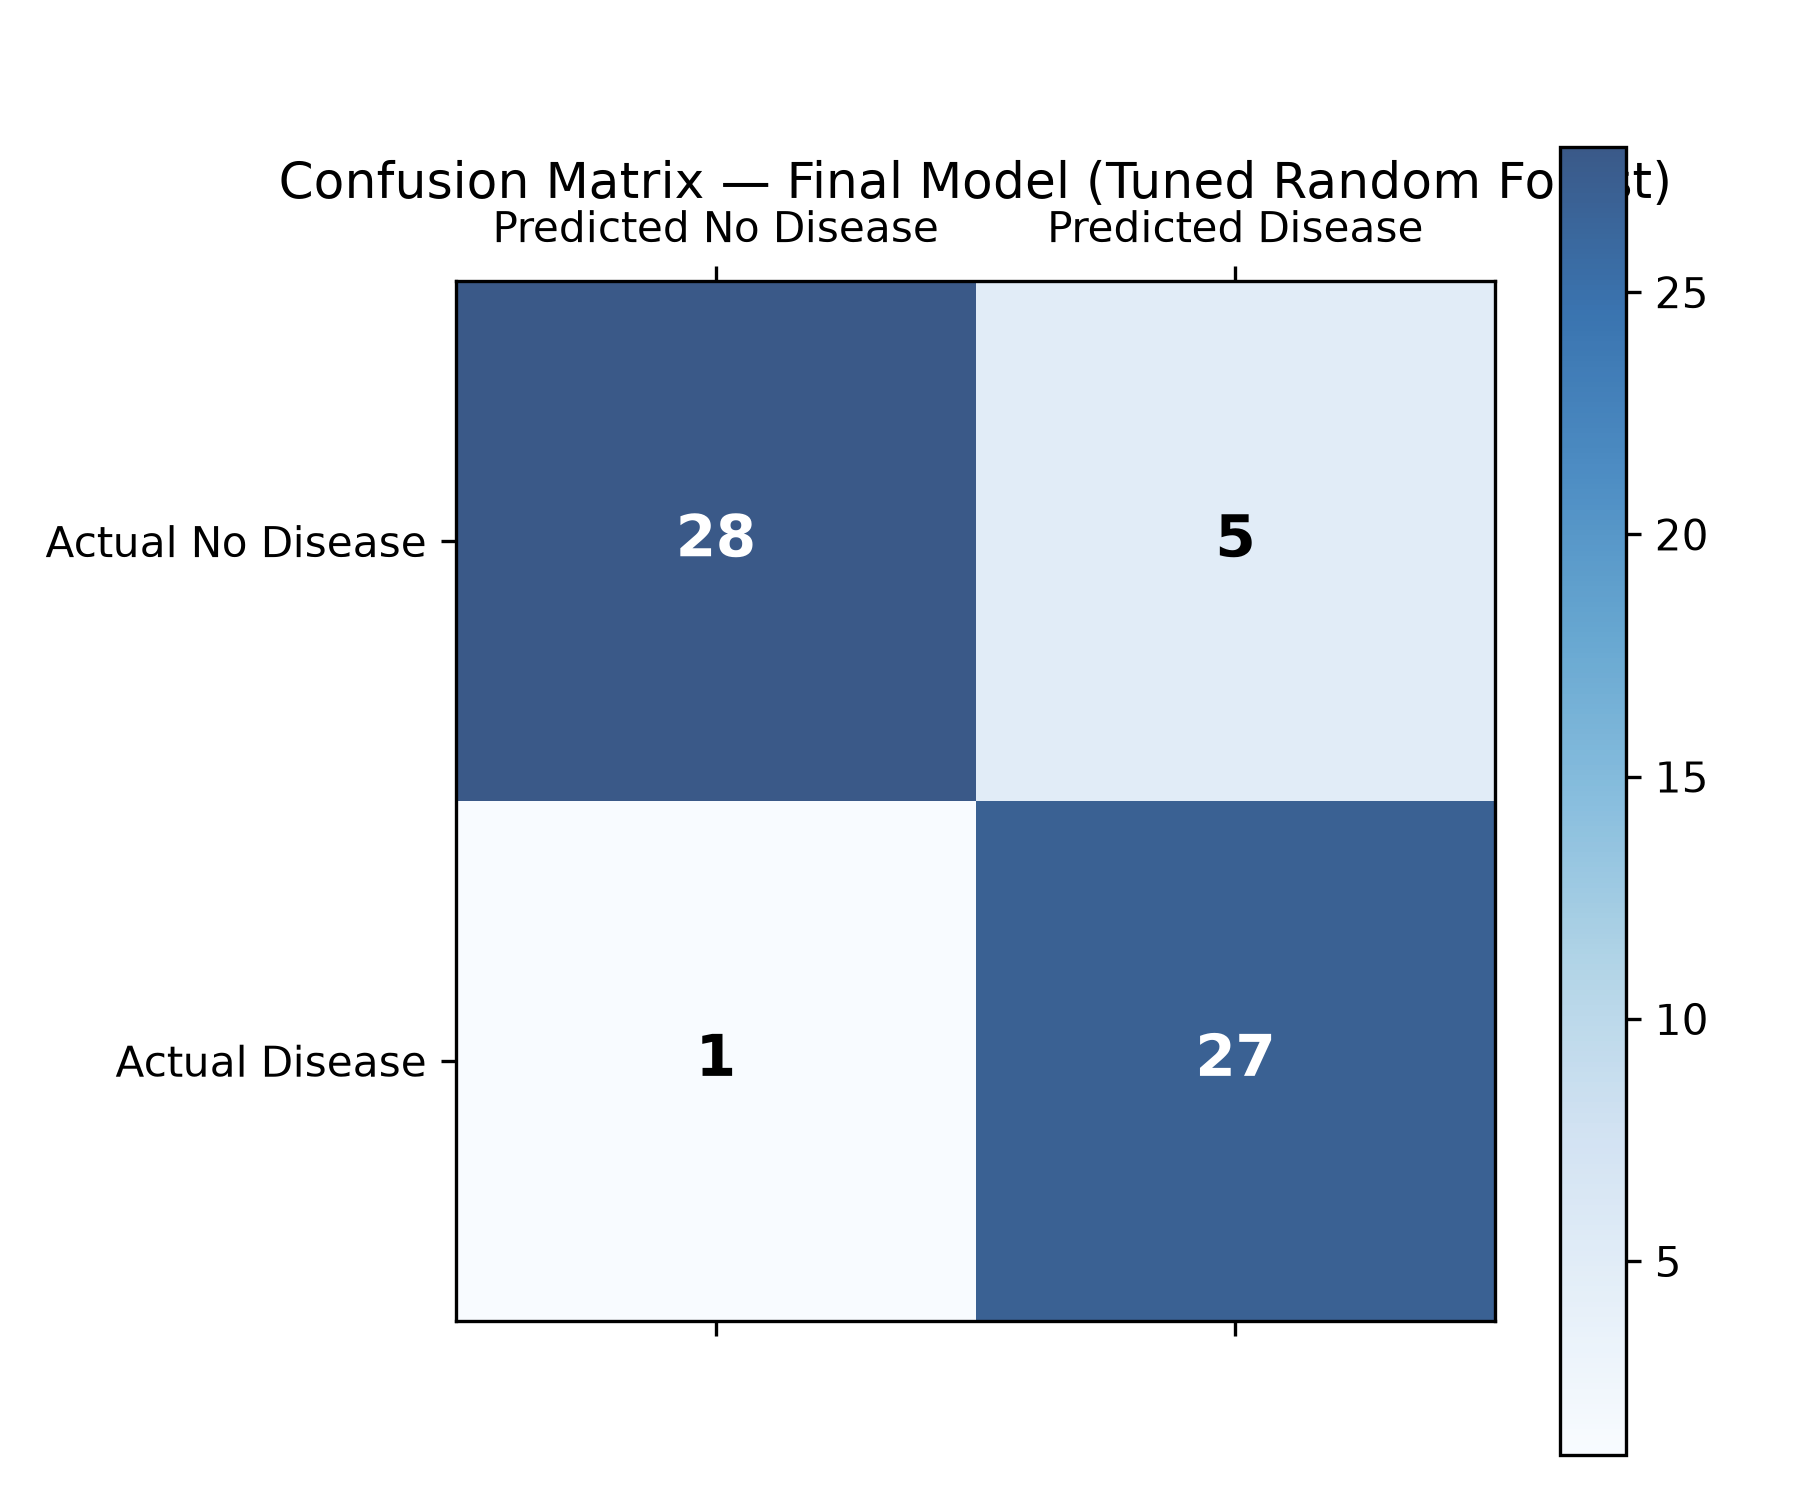

In [5]:
from IPython.display import Image, display

fig_dir = Path("../results/figures/")
if not fig_dir.exists():
    fig_dir = Path("results/figures/")

cm_file = fig_dir / "final_model_confusion_matrix.png"
if cm_file.exists():
    display(Image(filename=str(cm_file)))


## 12. ROC Curve

Receiver Operating Characteristic (ROC) curve for the final model:


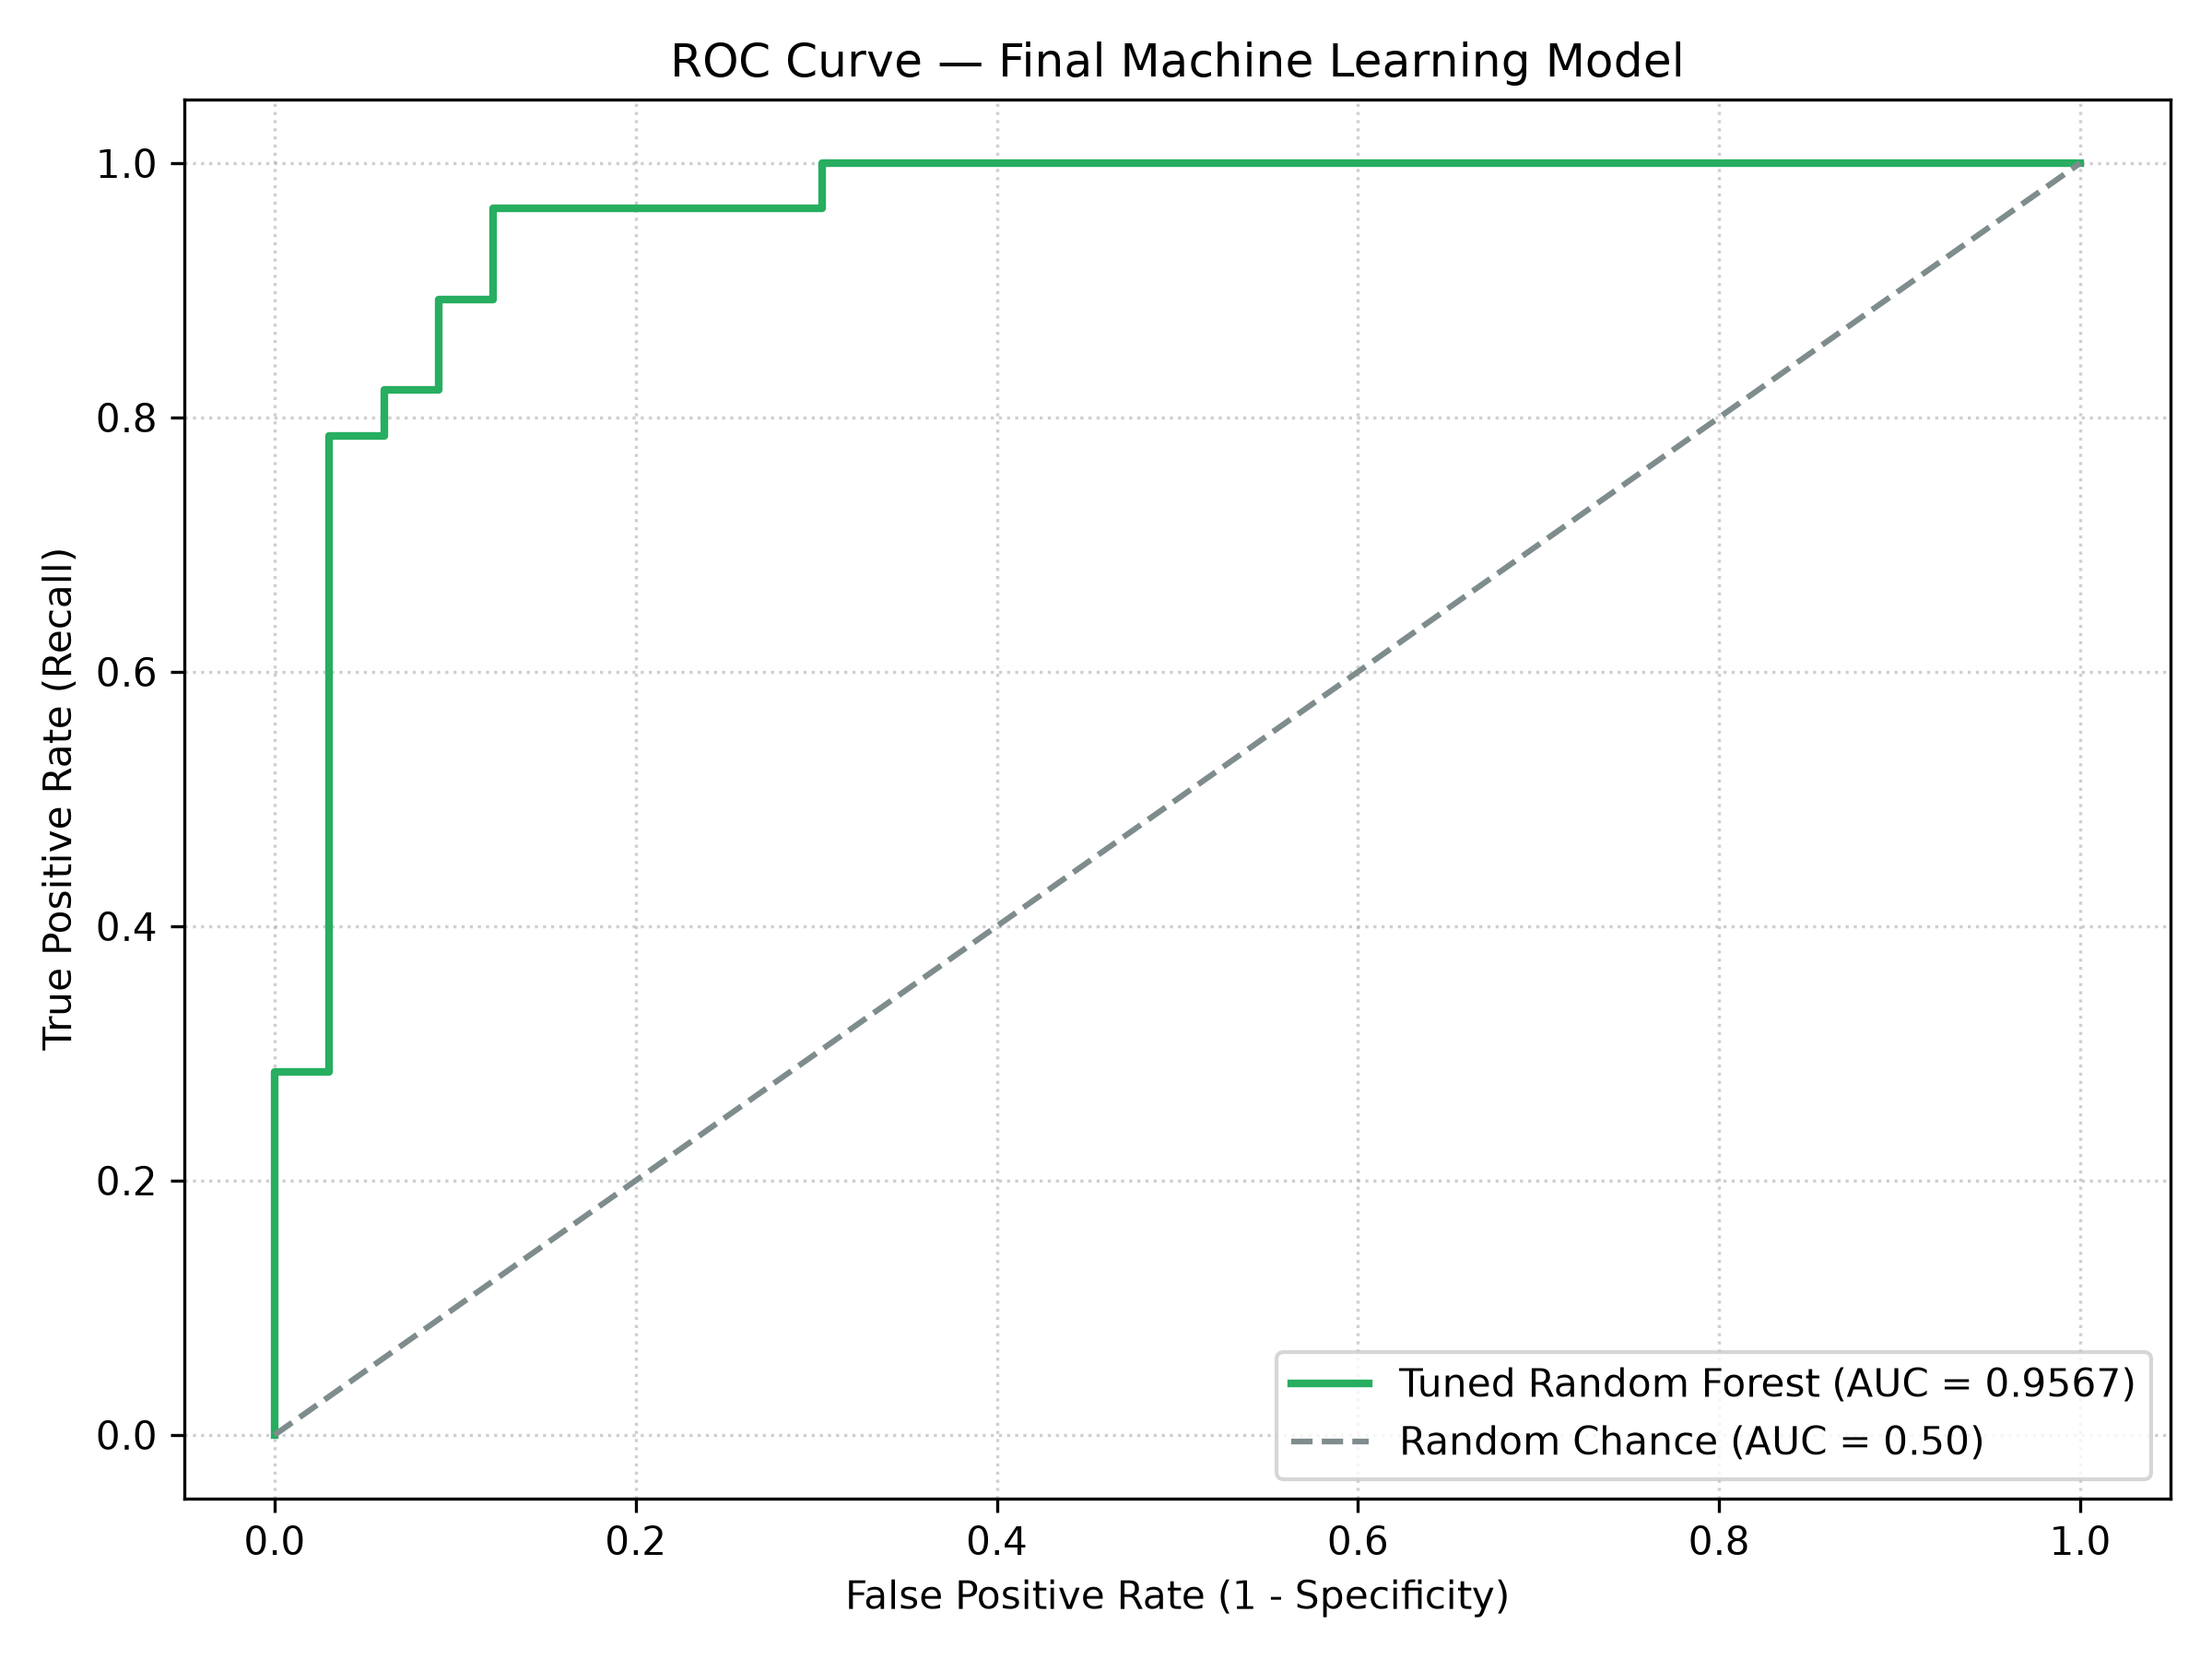

In [6]:
roc_file = fig_dir / "final_model_roc_curve.png"
if roc_file.exists():
    display(Image(filename=str(roc_file)))


## 13. Feature Importance / Interpretability

Top clinical feature drivers identified by Gini feature importance:


In [7]:
fi_df = pd.read_csv(Path("../results/final_feature_importance.csv") if Path("../results/final_feature_importance.csv").exists() else Path("results/final_feature_importance.csv"))
fi_df.head(10)


,Feature,Importance,Percentage
0,thal_3.0,0.102302,10.230213
1,ca_0.0,0.088825,8.882454
2,thal_7.0,0.085238,8.523797
3,cp_4.0,0.079117,7.911687
4,thalach,0.078717,7.871708
5,oldpeak,0.073489,7.348940
6,age,0.068069,6.806946
7,chol,0.059385,5.938511
8,trestbps,0.052347,5.234658
9,exang_1.0,0.038756,3.875624


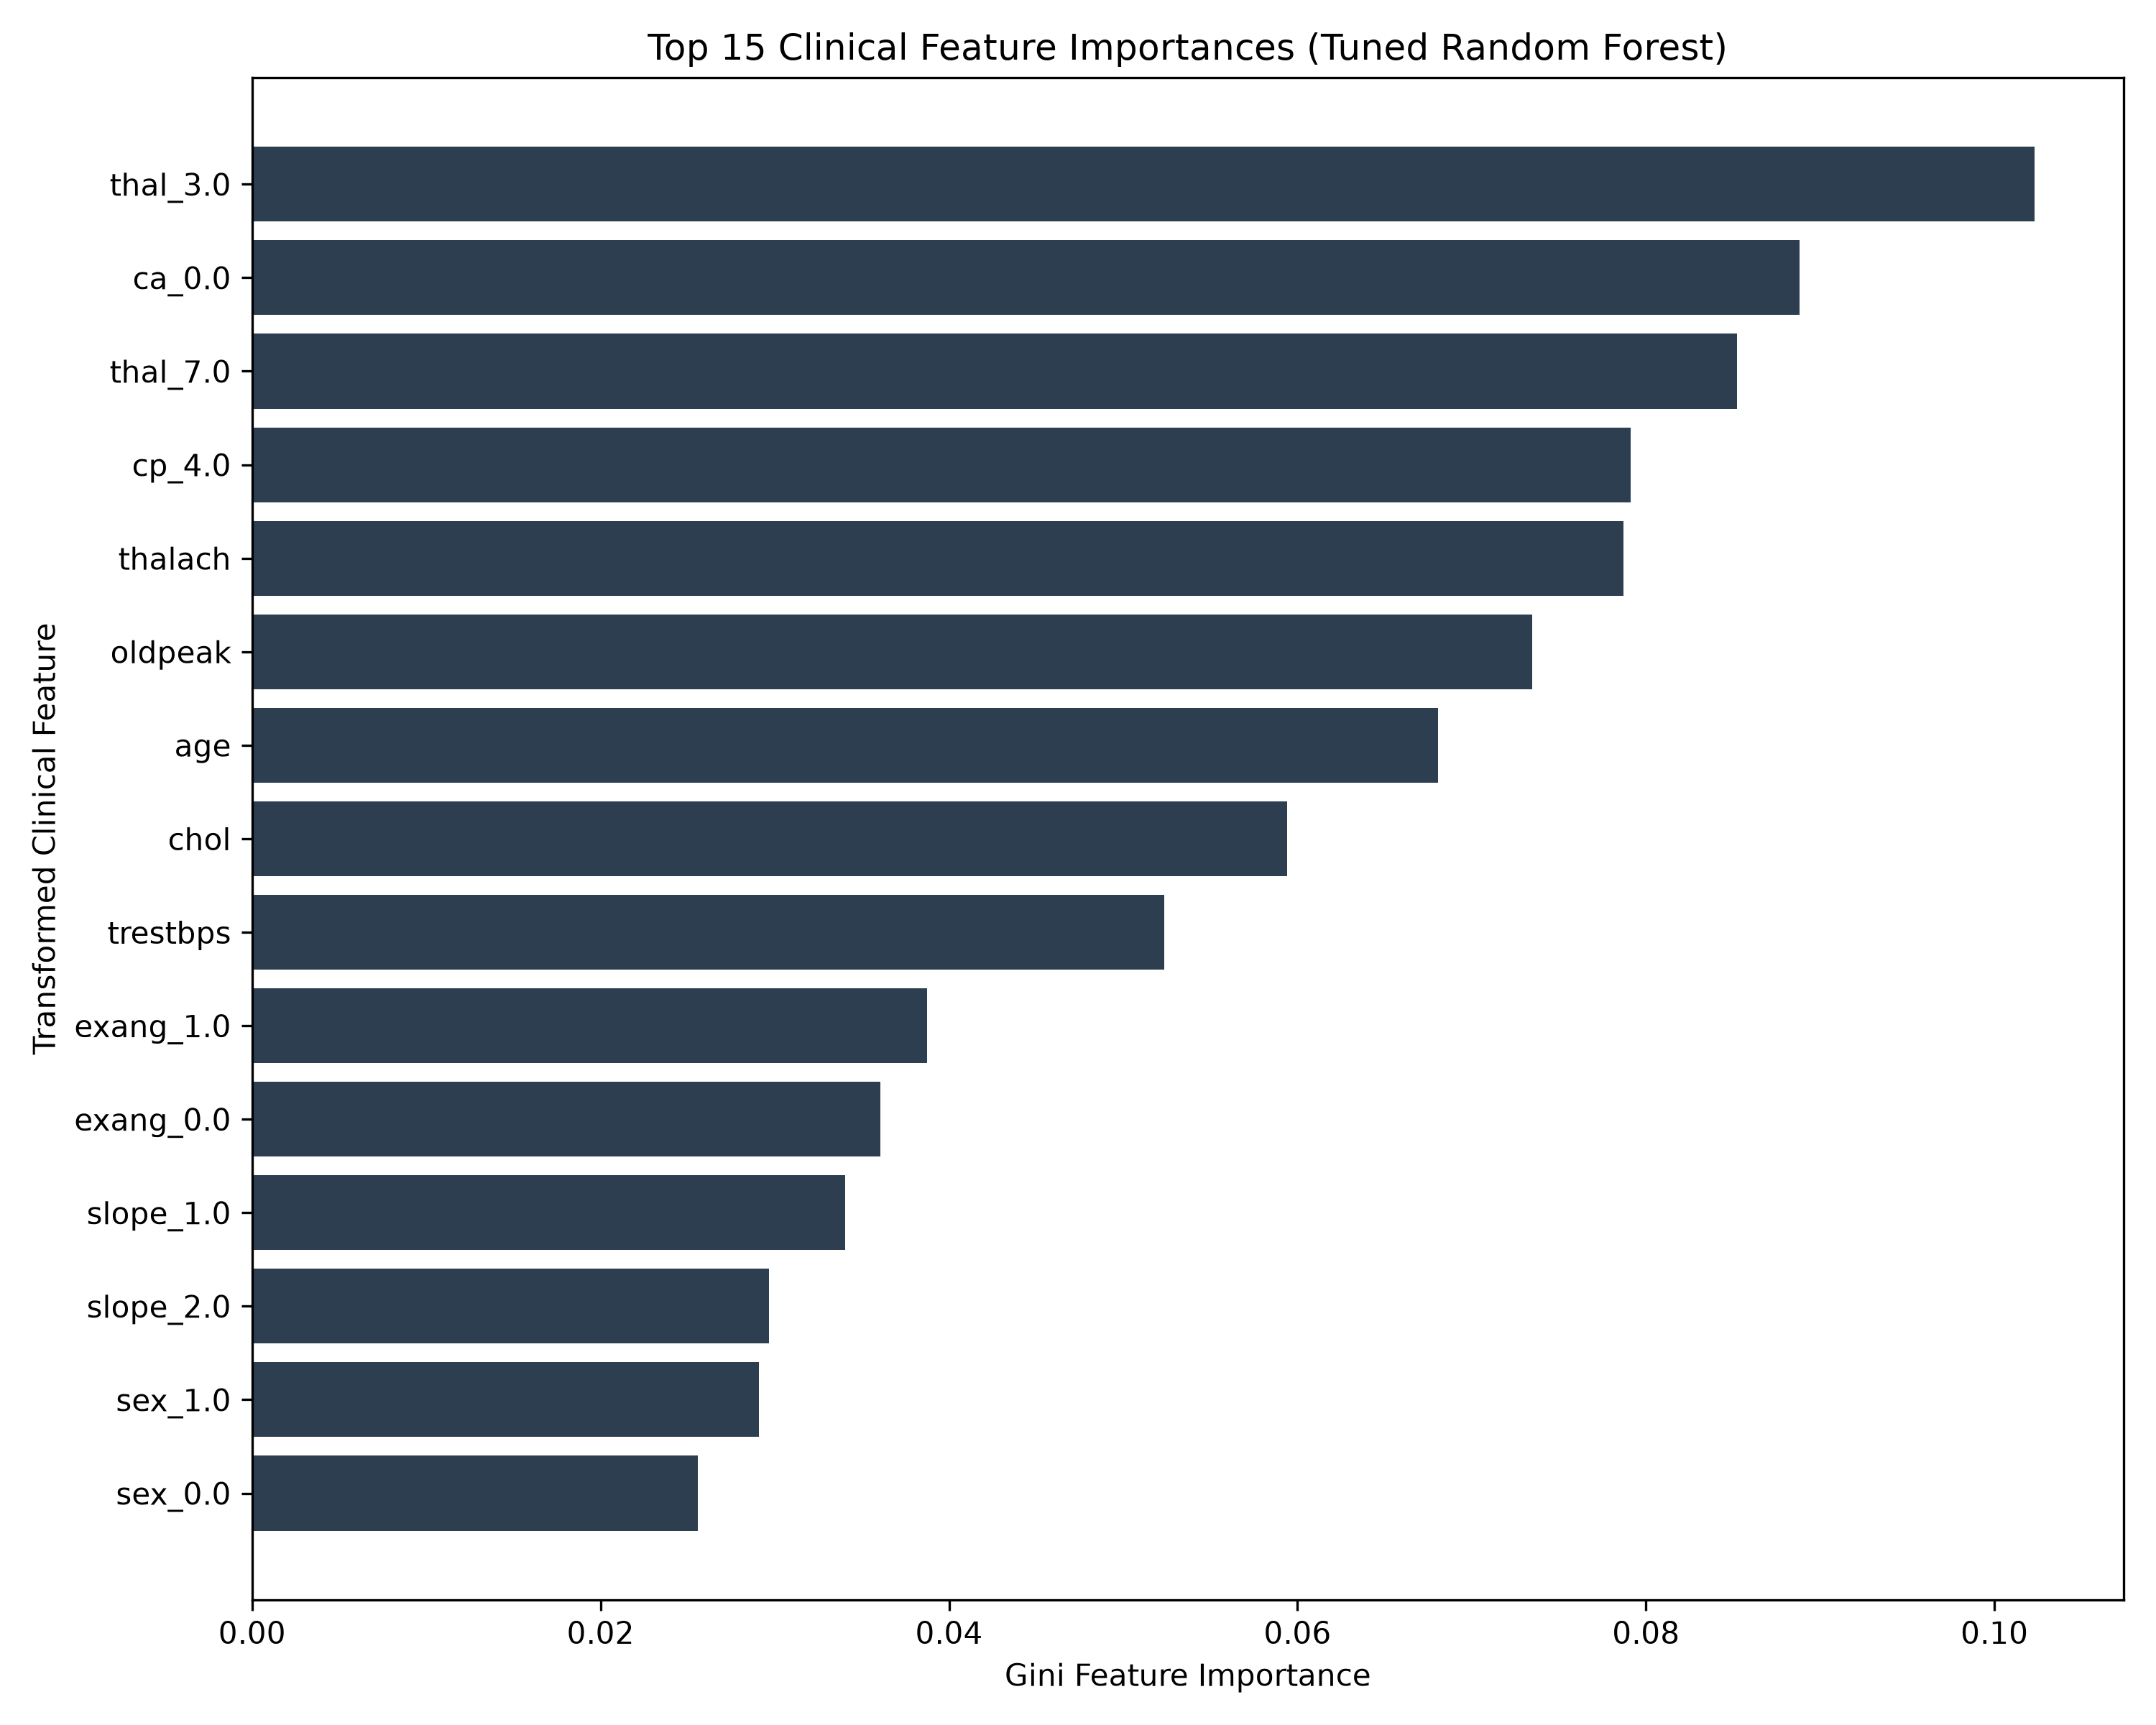

In [8]:
fi_fig = fig_dir / "final_feature_importance.png"
if fi_fig.exists():
    display(Image(filename=str(fi_fig)))


## 14. Prediction Demonstration

Demonstration of the end-to-end inference routine `predict_heart_disease()` on sample patient inputs:


In [9]:
import sys
proj_dir = Path("..").resolve() if Path("../src").exists() else Path(".").resolve()
if str(proj_dir) not in sys.path:
    sys.path.insert(0, str(proj_dir))

from src.predict import predict_heart_disease

sample_patient = {
    "age": 63,
    "sex": 1,
    "cp": 3,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 0,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 0,
    "ca": 0,
    "thal": 1
}

res = predict_heart_disease(sample_patient, model_path=str(models_dir / "final_model.joblib"))
print("Prediction Result:")
print("Predicted Class:      ", res["predicted_class"][0])
print("Predicted Label:      ", res["predicted_label"][0])
print("Disease Probability:  ", f"{res['probability_disease'][0]:.4f}")
print("Formatted Message:    ", res["prediction_message"][0])


Prediction Result:
Predicted Class:       0
Predicted Label:       No Heart Disease
Disease Probability:   0.3812
Formatted Message:     Model prediction: No Heart Disease (Probability: 0.3812)


## 15. Limitations

- **Dataset Size**: 303 total patient records (242 train, 61 test).
- **Academic Scope**: Built strictly for educational research. Predictions represent statistical model estimates, not clinical diagnosis.


## 16. Conclusion

Tuned Random Forest was selected as the final machine learning model. It achieved superior test recall (0.9643) and accuracy (0.9016), minimizing false negatives to 1 on the test set. The complete pipeline artifact is saved at `models/final/final_model.joblib`.
